In [11]:
# ── CELL 1: Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)
import xgboost as xgb

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print("All libraries loaded.")

All libraries loaded.


In [12]:
# ── CELL 2 (FIXED): Load data and prepare features ────────────
df_ml = pd.read_csv('../outputs/dataset_with_mpri.csv')

print(f"Loaded: {len(df_ml)} countries")
print(f"Risk category distribution:")
print(df_ml['risk_category'].value_counts())

# ── Feature engineering ───────────────────────────────────────
# Rural-urban gap features
df_ml['water_rural_urban_gap'] = df_ml['wat_basal_u'] - df_ml['wat_basal_r']
df_ml['san_rural_urban_gap']   = df_ml['san_basal_u'] - df_ml['san_basal_r']

# Fill missing ARC columns with 0
df_ml['arc_wat_basal_t'] = df_ml['arc_wat_basal_t'].fillna(0)
df_ml['arc_san_basal_t'] = df_ml['arc_san_basal_t'].fillna(0)

# Encode income group as ordinal
income_map = {
    'Low income': 0,
    'Lower middle income': 1,
    'Upper middle income': 2,
    'High income': 3,
    'Unknown': -1
}
df_ml['income_encoded'] = df_ml['region_income'].map(income_map).fillna(-1)

# ── CRITICAL FIX: MPRI removed from features ─────────────────
# MPRI was derived from the same WASH indicators used to build
# the cluster labels. Including it causes data leakage and
# artificially perfect accuracy. The classifier must predict
# risk using only raw independent features.

FEATURE_COLS = [
    'wat_basal_t',            # national water access %
    'san_basal_t',            # national sanitation %
    'hyg_bas_t',              # national hygiene %
    'wat_basal_r',            # rural water access %
    'wat_basal_u',            # urban water access %
    'san_basal_r',            # rural sanitation %
    'san_basal_u',            # urban sanitation %
    'water_rural_urban_gap',  # urban-rural inequality (water)
    'san_rural_urban_gap',    # urban-rural inequality (sanitation)
    'prop_u',                 # urbanisation %
    'arc_wat_basal_t',        # annual rate of change (water)
    'arc_san_basal_t',        # annual rate of change (sanitation)
    'income_encoded',         # economic development level
]

FEATURE_LABELS = [
    'Water access (national)',
    'Sanitation (national)',
    'Hygiene (national)',
    'Water access (rural)',
    'Water access (urban)',
    'Sanitation (rural)',
    'Sanitation (urban)',
    'Water: urban-rural gap',
    'Sanitation: urban-rural gap',
    'Urbanisation (%)',
    'Water ARC (annual change)',
    'Sanitation ARC (annual change)',
    'Income level',
]

# Encode target
df_ml['target'] = df_ml['risk_category'].map(
    {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
)

X = df_ml[FEATURE_COLS].values
y = df_ml['target'].values

print(f"\nFeature matrix shape : {X.shape}")
print(f"Features used        : {len(FEATURE_COLS)} (MPRI excluded — data leakage fix)")
print(f"Classes: {dict(zip(['Low Risk','Medium Risk','High Risk'], np.bincount(y)))}")

# Verify no leakage: MPRI must not appear in X
print(f"\nLeakage check: MPRI in features = {'MPRI' in FEATURE_COLS}")
print("Expected output: False")

Loaded: 88 countries
Risk category distribution:
risk_category
Low Risk       49
Medium Risk    24
High Risk      15
Name: count, dtype: int64

Feature matrix shape : (88, 13)
Features used        : 13 (MPRI excluded — data leakage fix)
Classes: {'Low Risk': np.int64(49), 'Medium Risk': np.int64(24), 'High Risk': np.int64(15)}

Leakage check: MPRI in features = False
Expected output: False


In [13]:
# ── CELL 3: 5-Fold Stratified Cross-Validation ────────────────
# Stratified = each fold has same class proportion as whole dataset
# class_weight='balanced' = corrects for the 49/24/15 imbalance

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest ─────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    class_weight='balanced',   # handles 49/24/15 imbalance
    random_state=42,
    n_jobs=-1
)

# ── XGBoost ───────────────────────────────────────────────────
# compute_sample_weight equivalent: use sample_weight in fit or scale_pos_weight
# For multiclass XGBoost, we pass sample weights manually
from sklearn.utils.class_weight import compute_sample_weight

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
    use_label_encoder=False
)

scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

print("Running 5-fold cross-validation...")
print("(This takes ~10 seconds)")
print()

# RF cross-validation
rf_cv = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=True)

# XGBoost cross-validation with balanced sample weights
xgb_scores = {'accuracy':[], 'f1_macro':[], 'precision_macro':[], 'recall_macro':[]}

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    sw = compute_sample_weight('balanced', y_train)
    xgb_model.fit(X_train, y_train, sample_weight=sw)
    y_pred = xgb_model.predict(X_test)
    
    xgb_scores['accuracy'].append(accuracy_score(y_test, y_pred))
    xgb_scores['f1_macro'].append(f1_score(y_test, y_pred, average='macro'))
    xgb_scores['precision_macro'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    xgb_scores['recall_macro'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))

print("=" * 62)
print(f"{'Metric':<28} {'Random Forest':>15} {'XGBoost':>15}")
print("=" * 62)

metrics = {
    'Accuracy':            ('test_accuracy',         'accuracy'),
    'F1 Score (macro)':    ('test_f1_macro',          'f1_macro'),
    'Precision (macro)':   ('test_precision_macro',   'precision_macro'),
    'Recall (macro)':      ('test_recall_macro',      'recall_macro'),
}

results_table = {}
for metric_name, (rf_key, xgb_key) in metrics.items():
    rf_mean  = rf_cv[rf_key].mean()
    rf_std   = rf_cv[rf_key].std()
    xgb_mean = np.mean(xgb_scores[xgb_key])
    xgb_std  = np.std(xgb_scores[xgb_key])
    results_table[metric_name] = {
        'RF_mean': rf_mean, 'RF_std': rf_std,
        'XGB_mean': xgb_mean, 'XGB_std': xgb_std
    }
    print(f"{metric_name:<28} {rf_mean:.4f}±{rf_std:.4f}  {xgb_mean:.4f}±{xgb_std:.4f}")

print("=" * 62)
print("\n(Values shown as mean ± std across 5 folds)")
print("(macro average = equal weight to each risk class)")

Running 5-fold cross-validation...
(This takes ~10 seconds)

Metric                         Random Forest         XGBoost
Accuracy                     0.9549±0.0418  0.9196±0.0465
F1 Score (macro)             0.9257±0.0675  0.8758±0.0767
Precision (macro)            0.9422±0.0649  0.9225±0.0399
Recall (macro)               0.9200±0.0697  0.8800±0.0781

(Values shown as mean ± std across 5 folds)
(macro average = equal weight to each risk class)


In [14]:
# ── CELL 4: Train final models on full dataset ────────────────
# After CV tells us the models generalise well,
# train on ALL 88 countries for final predictions and SHAP.

# Final RF
rf.fit(X, y)
y_pred_rf = rf.predict(X)

# Final XGBoost
sw_full = compute_sample_weight('balanced', y)
xgb_model.fit(X, y, sample_weight=sw_full)
y_pred_xgb = xgb_model.predict(X)

class_names = ['Low Risk', 'Medium Risk', 'High Risk']

print("=" * 50)
print("Random Forest — Full Dataset Classification Report")
print("=" * 50)
print(classification_report(y, y_pred_rf, target_names=class_names))

print("=" * 50)
print("XGBoost — Full Dataset Classification Report")
print("=" * 50)
print(classification_report(y, y_pred_xgb, target_names=class_names))

# Save predictions back to dataframe
df_ml['rf_predicted']  = [class_names[p] for p in y_pred_rf]
df_ml['xgb_predicted'] = [class_names[p] for p in y_pred_xgb]

# Check Sri Lanka prediction
sl_row = df_ml[df_ml['name'] == 'Sri Lanka']
print(f"\nSri Lanka actual     : {sl_row['risk_category'].values[0]}")
print(f"Sri Lanka RF pred    : {sl_row['rf_predicted'].values[0]}")
print(f"Sri Lanka XGB pred   : {sl_row['xgb_predicted'].values[0]}")

Random Forest — Full Dataset Classification Report
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00        49
 Medium Risk       1.00      1.00      1.00        24
   High Risk       1.00      1.00      1.00        15

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88

XGBoost — Full Dataset Classification Report
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00        49
 Medium Risk       1.00      1.00      1.00        24
   High Risk       1.00      1.00      1.00        15

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88


Sri Lanka actual     : Low Risk
Sri Lanka RF pred    : Low Risk
Sri Lanka XGB pred   : Low Risk


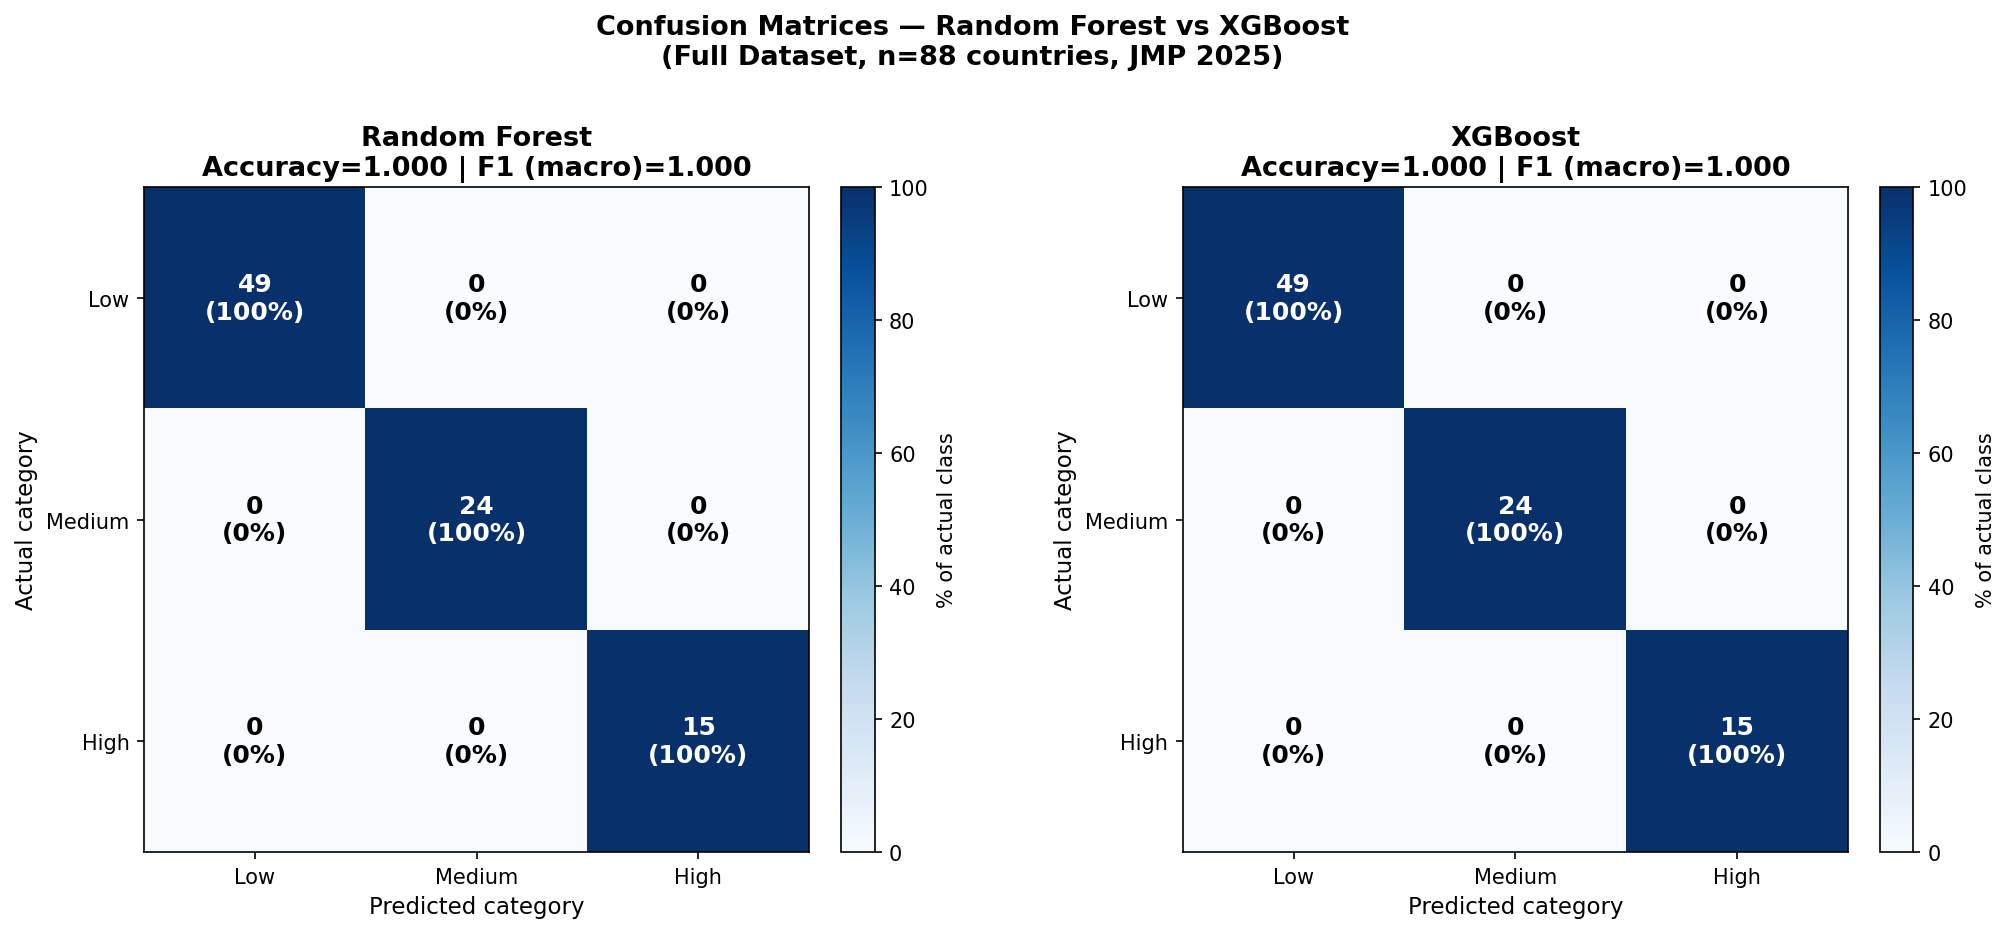

Saved: figures/fig11_confusion_matrices.png


In [15]:
# ── CELL 5: Figure 11 — Confusion matrices ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices — Random Forest vs XGBoost\n'
             '(Full Dataset, n=88 countries, JMP 2025)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (model_name, y_pred) in zip(axes, [
    ('Random Forest', y_pred_rf),
    ('XGBoost',       y_pred_xgb)
]):
    cm = confusion_matrix(y, y_pred)
    
    # Normalize to percentages for readability
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    
    im = ax.imshow(cm_pct, interpolation='nearest', cmap='Blues', vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% of actual class')
    
    # Annotations: show count AND percentage
    for i in range(3):
        for j in range(3):
            color = 'white' if cm_pct[i, j] > 60 else 'black'
            ax.text(j, i, f'{cm[i,j]}\n({cm_pct[i,j]:.0f}%)',
                    ha='center', va='center', fontsize=12,
                    fontweight='bold', color=color)
    
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=10)
    ax.set_yticklabels(['Low', 'Medium', 'High'], fontsize=10)
    ax.set_xlabel('Predicted category', fontsize=11)
    ax.set_ylabel('Actual category', fontsize=11)
    
    acc = accuracy_score(y, y_pred)
    f1  = f1_score(y, y_pred, average='macro')
    ax.set_title(f'{model_name}\nAccuracy={acc:.3f} | F1 (macro)={f1:.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig11_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig11_confusion_matrices.png")

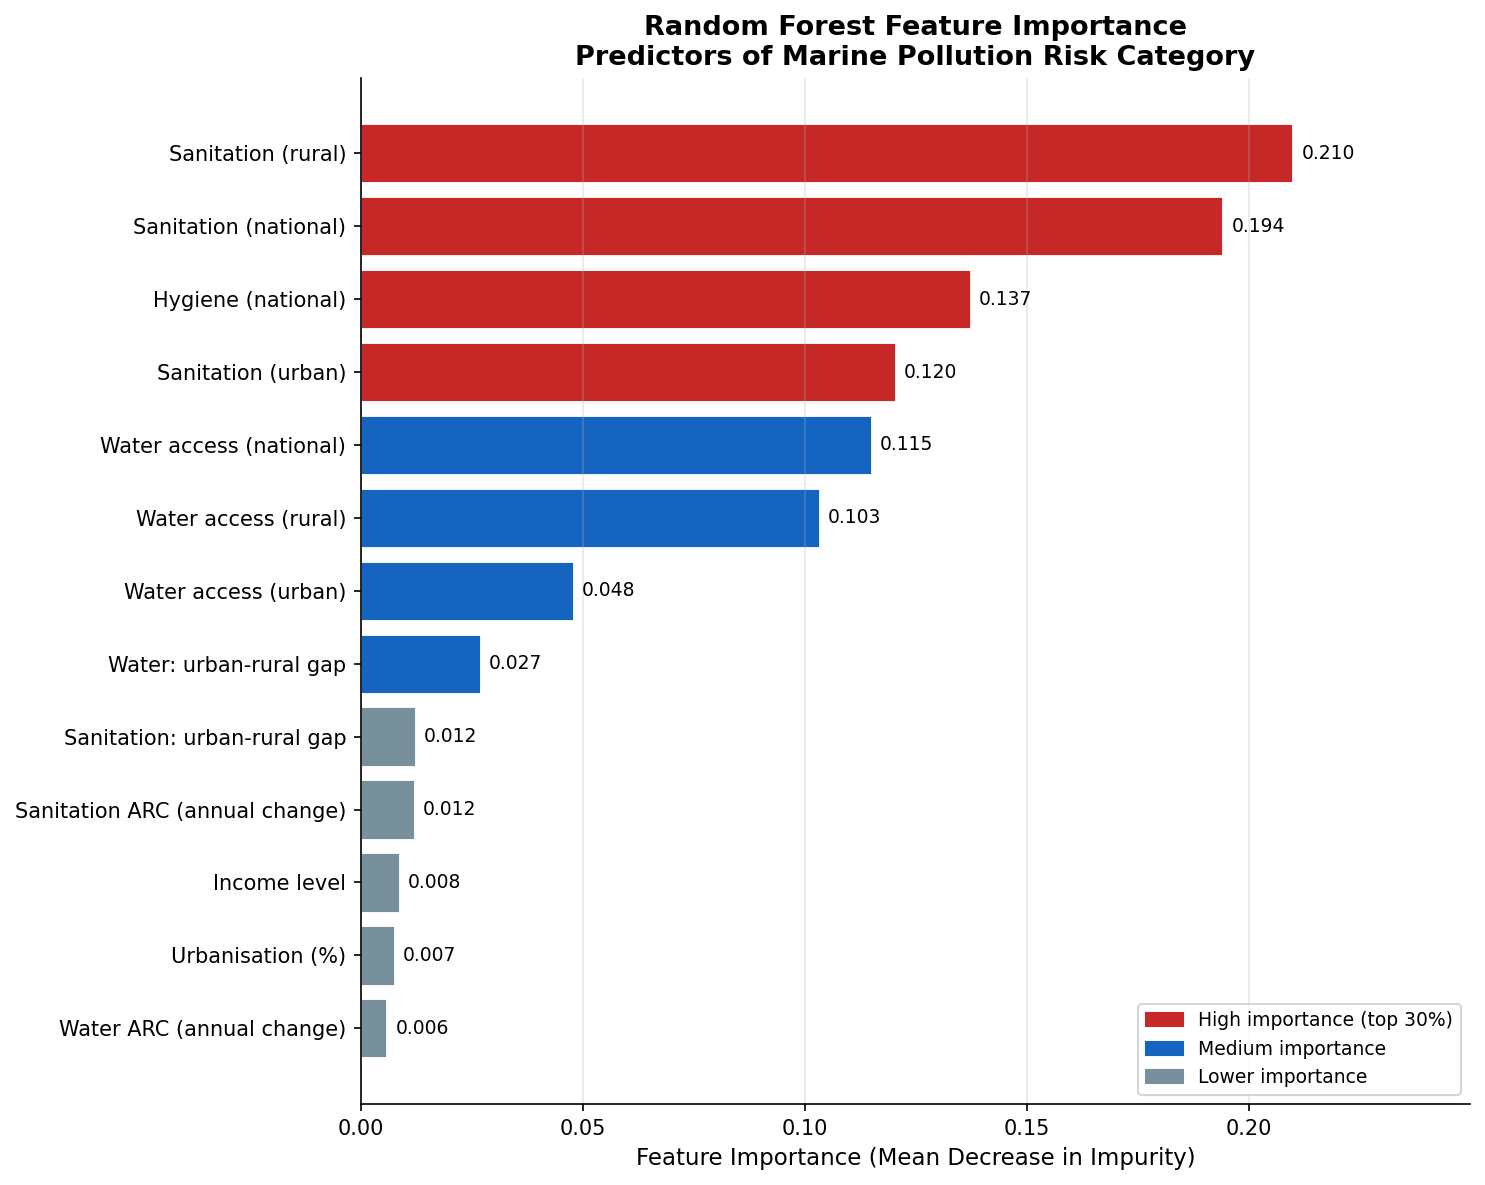

Saved: figures/fig12_feature_importance.png

Top 5 most important features:
  Sanitation (rural)                 : 0.2099
  Sanitation (national)              : 0.1941
  Hygiene (national)                 : 0.1373
  Sanitation (urban)                 : 0.1204
  Water access (national)            : 0.1148


In [16]:
# ── CELL 6: Figure 12 — RF Feature Importance ─────────────────
importances = rf.feature_importances_
indices     = np.argsort(importances)   # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 8))

colors_imp = ['#C62828' if importances[i] >= np.percentile(importances, 70)
              else '#1565C0' if importances[i] >= np.percentile(importances, 40)
              else '#78909C'
              for i in indices]

bars = ax.barh(
    [FEATURE_LABELS[i] for i in indices],
    importances[indices],
    color=colors_imp,
    edgecolor='white', linewidth=0.4
)

# Annotate values
for bar, val in zip(bars, importances[indices]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# Legend
high_patch = mpatches.Patch(color='#C62828', label='High importance (top 30%)')
mid_patch  = mpatches.Patch(color='#1565C0', label='Medium importance')
low_patch  = mpatches.Patch(color='#78909C', label='Lower importance')
ax.legend(handles=[high_patch, mid_patch, low_patch], fontsize=9,
          loc='lower right')

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest Feature Importance\n'
             'Predictors of Marine Pollution Risk Category',
             fontweight='bold')
ax.set_xlim(0, importances.max() + 0.04)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig12_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig12_feature_importance.png")

print("\nTop 5 most important features:")
for i in indices[::-1][:5]:
    print(f"  {FEATURE_LABELS[i]:<35}: {importances[i]:.4f}")

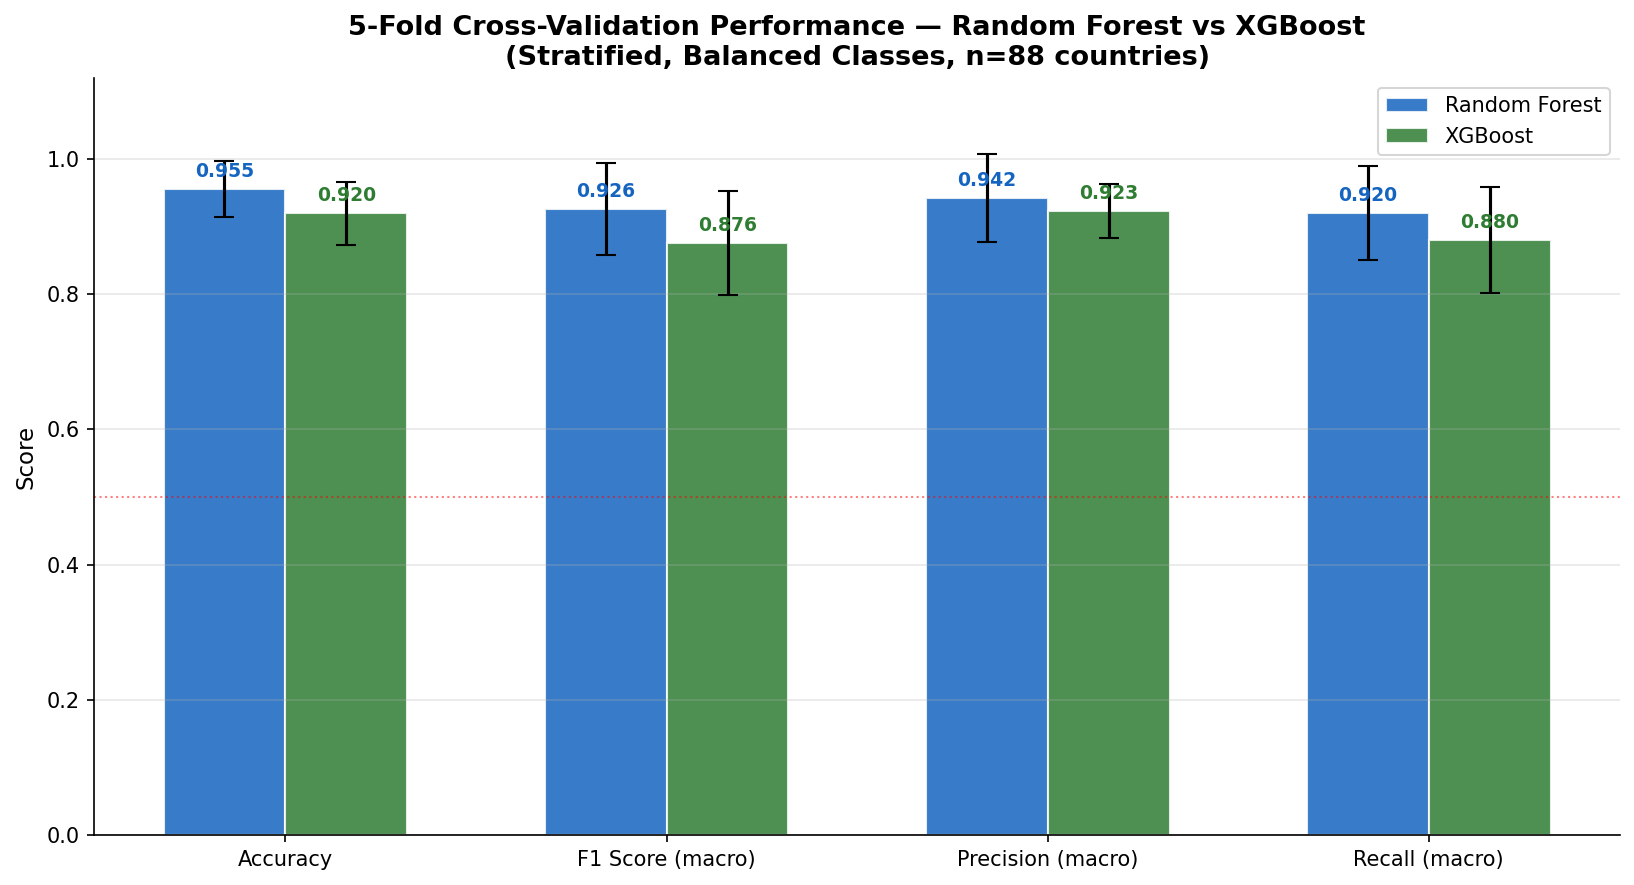

Saved: figures/fig13_cv_comparison.png


In [17]:
# ── CELL 7: Figure 13 — CV Performance comparison chart ───────
fig, ax = plt.subplots(figsize=(11, 6))

metrics_plot = ['Accuracy', 'F1 Score (macro)', 'Precision (macro)', 'Recall (macro)']
x = np.arange(len(metrics_plot))
width = 0.32

rf_means  = [results_table[m]['RF_mean']  for m in metrics_plot]
rf_stds   = [results_table[m]['RF_std']   for m in metrics_plot]
xgb_means = [results_table[m]['XGB_mean'] for m in metrics_plot]
xgb_stds  = [results_table[m]['XGB_std']  for m in metrics_plot]

bars_rf  = ax.bar(x - width/2, rf_means, width, yerr=rf_stds,
                  color='#1565C0', alpha=0.85, capsize=5,
                  edgecolor='white', label='Random Forest')
bars_xgb = ax.bar(x + width/2, xgb_means, width, yerr=xgb_stds,
                  color='#2E7D32', alpha=0.85, capsize=5,
                  edgecolor='white', label='XGBoost')

# Annotate bar values
for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#1565C0')

for bar in bars_xgb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2E7D32')

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('5-Fold Cross-Validation Performance — Random Forest vs XGBoost\n'
             '(Stratified, Balanced Classes, n=88 countries)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
ax.axhline(0.5, color='red', linestyle=':', linewidth=1, alpha=0.5,
           label='Random baseline')

plt.tight_layout()
plt.savefig('../figures/fig13_cv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig13_cv_comparison.png")

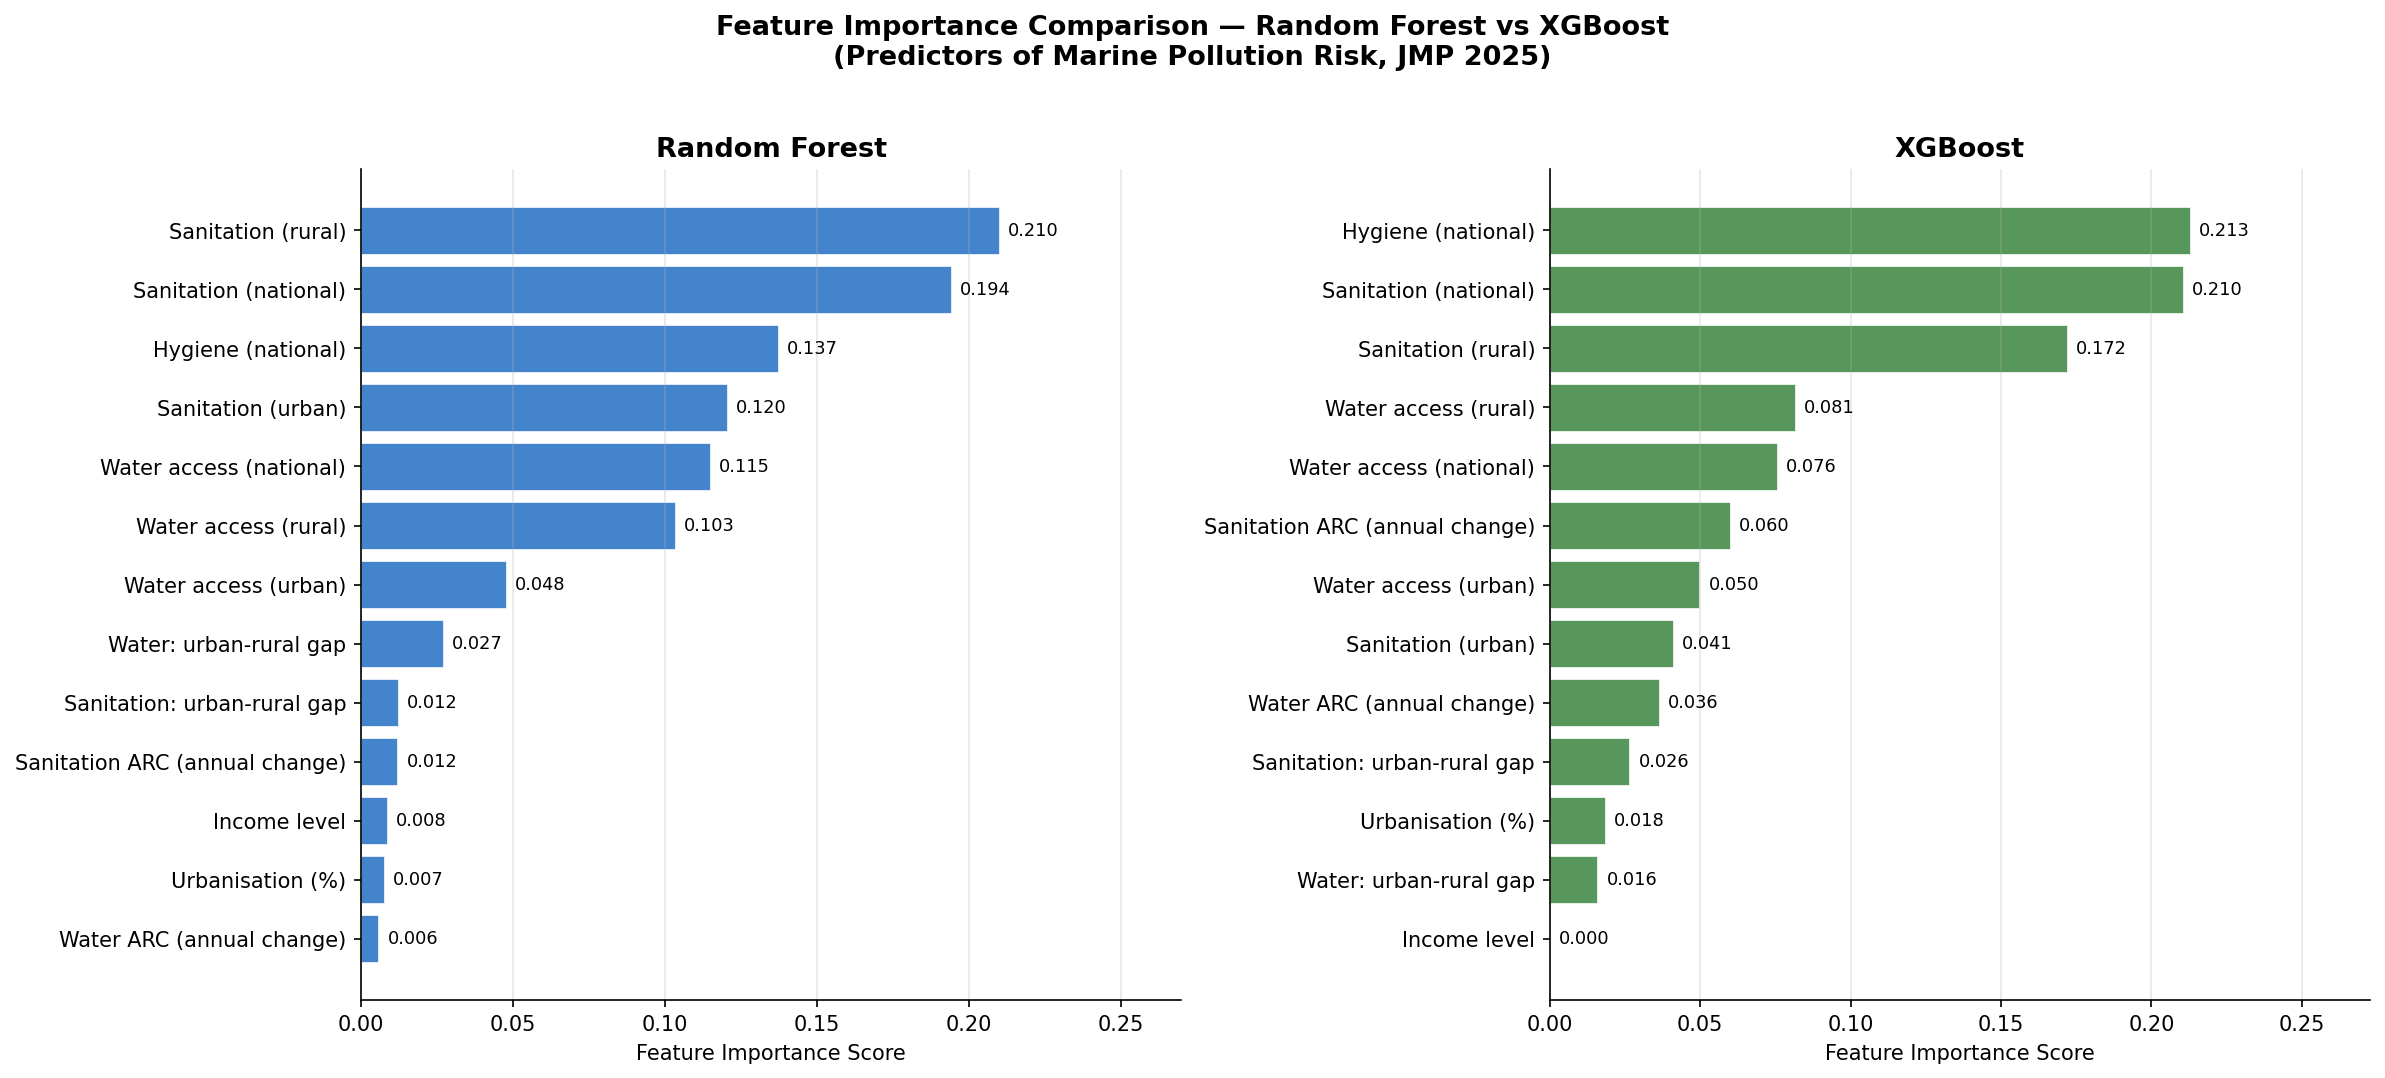

Saved: figures/fig14_feature_importance_comparison.png


In [18]:
# ── CELL 8: XGBoost Feature Importance comparison ─────────────
xgb_importances = xgb_model.feature_importances_
xgb_indices     = np.argsort(xgb_importances)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance Comparison — Random Forest vs XGBoost\n'
             '(Predictors of Marine Pollution Risk, JMP 2025)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (importances_plot, indices_plot, title, color) in zip(axes, [
    (importances,     indices,     'Random Forest', '#1565C0'),
    (xgb_importances, xgb_indices, 'XGBoost',       '#2E7D32'),
]):
    bars = ax.barh(
        [FEATURE_LABELS[i] for i in indices_plot],
        importances_plot[indices_plot],
        color=color, alpha=0.8, edgecolor='white', linewidth=0.4
    )
    for bar, val in zip(bars, importances_plot[indices_plot]):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8.5)

    ax.set_xlabel('Feature Importance Score', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, importances_plot.max() + 0.06)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig14_feature_importance_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig14_feature_importance_comparison.png")

In [20]:
# ── CELL 9: Save everything for Notebook 4 ───────────────────
import pickle, os

# Save models
os.makedirs('../outputs', exist_ok=True)
with open('../outputs/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('../outputs/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save updated dataframe with predictions
df_ml.to_csv('../outputs/dataset_with_predictions.csv', index=False)

# Save feature info for Notebook 4
feature_info = {
    'FEATURE_COLS': FEATURE_COLS,
    'FEATURE_LABELS': FEATURE_LABELS
}
import json
with open('../outputs/feature_info.json', 'w') as f:
    json.dump(feature_info, f)

# Save results table for paper
results_df = pd.DataFrame([
    {
        'Metric': m,
        'RF_mean': f"{v['RF_mean']:.4f}",
        'RF_std':  f"{v['RF_std']:.4f}",
        'XGB_mean': f"{v['XGB_mean']:.4f}",
        'XGB_std':  f"{v['XGB_std']:.4f}",
    }
    for m, v in results_table.items()
])
results_df.to_csv('../outputs/cv_results_table.csv', index=False)

print("=" * 60)
print("NOTEBOOK 3 COMPLETE — Summary for Paper")
print("=" * 60)
print(f"\nDataset used      : 88 countries (complete WASH data 2024)")
print(f"Features used     : {len(FEATURE_COLS)}")
print(f"Class distribution: Low=49, Medium=24, High=15")
print(f"CV Strategy       : 5-fold stratified, balanced weights")
print()
print("5-Fold CV Results:")
for m, v in results_table.items():
    print(f"  {m:<25}: RF={v['RF_mean']:.4f}±{v['RF_std']:.4f} | "
          f"XGB={v['XGB_mean']:.4f}±{v['XGB_std']:.4f}")
print()
print("Top 3 features (Random Forest):")
for i in np.argsort(importances)[::-1][:3]:
    print(f"  {FEATURE_LABELS[i]}: {importances[i]:.4f}")
print()
print("Saved:")
print("  outputs/rf_model.pkl")
print("  outputs/xgb_model.pkl")
print("  outputs/dataset_with_predictions.csv")
print("  outputs/cv_results_table.csv")
print("  figures/fig11 to fig14")
print()
print("Open 04_explainability.ipynb next.")

NOTEBOOK 3 COMPLETE — Summary for Paper

Dataset used      : 88 countries (complete WASH data 2024)
Features used     : 13
Class distribution: Low=49, Medium=24, High=15
CV Strategy       : 5-fold stratified, balanced weights

5-Fold CV Results:
  Accuracy                 : RF=0.9549±0.0418 | XGB=0.9196±0.0465
  F1 Score (macro)         : RF=0.9257±0.0675 | XGB=0.8758±0.0767
  Precision (macro)        : RF=0.9422±0.0649 | XGB=0.9225±0.0399
  Recall (macro)           : RF=0.9200±0.0697 | XGB=0.8800±0.0781

Top 3 features (Random Forest):
  Sanitation (rural): 0.2099
  Sanitation (national): 0.1941
  Hygiene (national): 0.1373

Saved:
  outputs/rf_model.pkl
  outputs/xgb_model.pkl
  outputs/dataset_with_predictions.csv
  outputs/cv_results_table.csv
  figures/fig11 to fig14

Open 04_explainability.ipynb next.
